# SASHIMI-C: ITAMAE migration demo

This notebook compares three explicitly named paths:

1. the established `sashimi_c` implementation (the reference),
2. `sashimi_c_itamae` with `physics_mode="legacy"` (strict reproduction), and
3. `sashimi_c_itamae` with `physics_mode="consistent"` (the opt-in default).

The calculation is intentionally small enough for a quick local or CI run, but it exercises the full weighted catalog, evolved and unevolved mass functions, and both cumulative satellite-count APIs.

## Environment

From the repository root, install the opt-in backend and notebook dependencies before running:

```bash
uv run --python 3.11 --extra demo jupyter-nbconvert --to notebook --execute --inplace itamae_migration_demo.ipynb
```

No random catalog sampling is used, so every table and curve below is deterministic.

In [1]:
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from sashimi_c import subhalo_observables as LegacyObservables
from sashimi_c import subhalo_properties as LegacyProperties
from sashimi_c_itamae import subhalo_observables as MigratedObservables
from sashimi_c_itamae import subhalo_properties as MigratedProperties

plt.style.use("seaborn-v0_8-whitegrid")
print(f"sashimi-c={version('sashimi-c')}, itamae={version('itamae')}")

sashimi-c=1.2.0, itamae=0.1.0a4


## Shared calculation conditions

All three paths use the same Milky-Way-mass host, CDM cosmology, accretion grid, concentration quadrature, stripping approximation, and no-disruption threshold. The reduced grid is for demonstration only; scientific production runs can increase these resolutions without changing the API.

In [2]:
CATALOG_PARAMETERS = {
    "M0": 1.0e12,
    "redshift": 0.0,
    "dz": 0.25,
    "zmax": 2.0,
    "N_ma": 32,
    "sigmalogc": 0.128,
    "N_herm": 5,
    "logmamin": 5.0,
    "logmamax": 10.0,
    "N_hermNa": 16,
    "Na_model": 3,
    "ct_th": 0.0,
    "profile_change": True,
    "method": "pert2_shanks",
}
OBSERVABLE_PARAMETERS = {
    ("M0_per_Msun" if name == "M0" else name): value
    for name, value in CATALOG_PARAMETERS.items()
}

display(Markdown(
    "| quantity | value |\n|---|---:|\n"
    + "\n".join(f"| `{name}` | `{value}` |" for name, value in CATALOG_PARAMETERS.items())
))

| quantity | value |
|---|---:|
| `M0` | `1000000000000.0` |
| `redshift` | `0.0` |
| `dz` | `0.25` |
| `zmax` | `2.0` |
| `N_ma` | `32` |
| `sigmalogc` | `0.128` |
| `N_herm` | `5` |
| `logmamin` | `5.0` |
| `logmamax` | `10.0` |
| `N_hermNa` | `16` |
| `Na_model` | `3` |
| `ct_th` | `0.0` |
| `profile_change` | `True` |
| `method` | `pert2_shanks` |

In [3]:
legacy_tuple = LegacyProperties().subhalo_properties_calc(**CATALOG_PARAMETERS)

migrated_legacy_properties = MigratedProperties(physics_mode="legacy")
migrated_legacy_tuple = migrated_legacy_properties.subhalo_properties_calc(
    **CATALOG_PARAMETERS
)
legacy_mode_catalog = migrated_legacy_properties.catalog

consistent_properties = MigratedProperties(physics_mode="consistent")
consistent_catalog = consistent_properties.subhalo_catalog_calc(**CATALOG_PARAMETERS)

legacy_observables = LegacyObservables(**OBSERVABLE_PARAMETERS)
migrated_legacy_observables = MigratedObservables(
    physics_mode="legacy", **OBSERVABLE_PARAMETERS
)
consistent_observables = MigratedObservables(
    physics_mode="consistent", **OBSERVABLE_PARAMETERS
)

print(
    f"catalog nodes={len(legacy_mode_catalog):,}; "
    f"surviving nodes={legacy_mode_catalog.metadata['surviving_node_count']:,}"
)

catalog nodes=1,280; surviving nodes=1,280


## API contracts

The migration is opt-in: importing `sashimi_c` still selects the established implementation. The migrated module retains the historical tuple method and additionally exposes the structured catalog method. `legacy` and `consistent` have the same API; only their recorded physical/numerical convention differs.

In [4]:
api_rows = [
    (
        "`sashimi_c.subhalo_properties_calc`",
        "established",
        f"tuple with {len(legacy_tuple)} arrays",
        "unchanged public contract",
    ),
    (
        "`sashimi_c_itamae.subhalo_properties_calc`",
        "legacy or consistent",
        f"tuple with {len(migrated_legacy_tuple)} arrays",
        "historical compatibility",
    ),
    (
        "`sashimi_c_itamae.subhalo_catalog_calc`",
        "legacy or consistent",
        type(legacy_mode_catalog).__name__,
        "named columns, split weights, provenance",
    ),
]
api_table = (
    "| call | physics mode | return value | purpose |\n"
    "|---|---|---|---|\n"
    + "\n".join("| " + " | ".join(row) + " |" for row in api_rows)
)
display(Markdown(api_table))
print("structured columns:", ", ".join(legacy_mode_catalog.columns))
print("structured weights:", ", ".join(legacy_mode_catalog.weights))

| call | physics mode | return value | purpose |
|---|---|---|---|
| `sashimi_c.subhalo_properties_calc` | established | tuple with 10 arrays | unchanged public contract |
| `sashimi_c_itamae.subhalo_properties_calc` | legacy or consistent | tuple with 10 arrays | historical compatibility |
| `sashimi_c_itamae.subhalo_catalog_calc` | legacy or consistent | WeightedSubhaloCatalog | named columns, split weights, provenance |

structured columns: m200_acc, z_acc, r_s_acc, rho_s_acc, m_bound, r_s, rho_s, c_t, survive
structured weights: weight_base, weight_concentration, weight_survival


## Numerical agreement and mode dependence

The first numerical column below is the migration acceptance check: migrated `legacy` must reproduce the true established implementation. The second column is not an error; it measures the deliberate effect of selecting the default `consistent` convention instead of strict reproduction.

In [5]:
def max_relative_difference(candidate, reference):
    candidate = np.asarray(candidate, dtype=float)
    reference = np.asarray(reference, dtype=float)
    floor = max(float(np.max(np.abs(reference))) * 1.0e-15, np.finfo(float).tiny)
    return float(np.max(np.abs(candidate - reference) / np.maximum(np.abs(reference), floor)))


def max_tuple_difference(candidate, reference):
    return max(
        max_relative_difference(candidate_value, reference_value)
        for candidate_value, reference_value in zip(candidate, reference, strict=True)
    )


def max_output_difference(candidate, reference):
    return max(
        max_relative_difference(candidate_value, reference_value)
        for candidate_value, reference_value in zip(candidate, reference, strict=True)
    )


def catalog_as_legacy_tuple(catalog):
    columns = catalog.columns
    weight = catalog.weights["weight_base"] * catalog.weights["weight_concentration"]
    return (
        columns["m200_acc"], columns["z_acc"], columns["r_s_acc"],
        columns["rho_s_acc"], columns["m_bound"], columns["r_s"],
        columns["rho_s"], columns["c_t"], weight, columns["survive"],
    )


consistent_tuple = catalog_as_legacy_tuple(consistent_catalog)
mpeak_threshold = 1.0e8 * legacy_observables.Msun
vpeak_threshold = 18.0 * legacy_observables.km / legacy_observables.s
legacy_mpeak = legacy_observables.Nsat_Mpeak(mpeak_threshold)
migrated_mpeak = migrated_legacy_observables.Nsat_Mpeak(mpeak_threshold)
consistent_mpeak = consistent_observables.Nsat_Mpeak(mpeak_threshold)
legacy_vpeak = legacy_observables.Nsat_Vpeak(vpeak_threshold)
migrated_vpeak = migrated_legacy_observables.Nsat_Vpeak(vpeak_threshold)
consistent_vpeak = consistent_observables.Nsat_Vpeak(vpeak_threshold)

comparisons = [
    (
        "full catalog (all numeric fields)",
        max_tuple_difference(migrated_legacy_tuple[:-1], legacy_tuple[:-1]),
        max_tuple_difference(consistent_tuple[:-1], migrated_legacy_tuple[:-1]),
    ),
    (
        "evolved mass function",
        max_output_difference(
            migrated_legacy_observables.mass_function(evolved=True),
            legacy_observables.mass_function(evolved=True),
        ),
        max_output_difference(
            consistent_observables.mass_function(evolved=True),
            migrated_legacy_observables.mass_function(evolved=True),
        ),
    ),
    (
        "unevolved mass function",
        max_output_difference(
            migrated_legacy_observables.mass_function(evolved=False),
            legacy_observables.mass_function(evolved=False),
        ),
        max_output_difference(
            consistent_observables.mass_function(evolved=False),
            migrated_legacy_observables.mass_function(evolved=False),
        ),
    ),
    (
        "cumulative satellite counts: Mpeak selection",
        max_output_difference(migrated_mpeak[1::2], legacy_mpeak[1::2]),
        max_output_difference(consistent_mpeak[1::2], migrated_mpeak[1::2]),
    ),
    (
        "Nsat mass/velocity axes: Mpeak selection",
        max_output_difference(migrated_mpeak[0::2], legacy_mpeak[0::2]),
        max_output_difference(consistent_mpeak[0::2], migrated_mpeak[0::2]),
    ),
    (
        "cumulative satellite counts: Vpeak selection",
        max_output_difference(migrated_vpeak[1::2], legacy_vpeak[1::2]),
        max_output_difference(consistent_vpeak[1::2], migrated_vpeak[1::2]),
    ),
    (
        "Nsat mass/velocity axes: Vpeak selection",
        max_output_difference(migrated_vpeak[0::2], legacy_vpeak[0::2]),
        max_output_difference(consistent_vpeak[0::2], migrated_vpeak[0::2]),
    ),
    (
        "annihilation boost (n=0, evolved)",
        max_output_difference(
            migrated_legacy_observables.annihilation_boost_factor(n=0),
            legacy_observables.annihilation_boost_factor(n=0),
        ),
        max_output_difference(
            consistent_observables.annihilation_boost_factor(n=0),
            migrated_legacy_observables.annihilation_boost_factor(n=0),
        ),
    ),
]

comparison_table = (
    "| result | migrated legacy vs established | consistent vs migrated legacy |\n"
    "|---|---:|---:|\n"
    + "\n".join(
        f"| {name} | {legacy_error:.3e} | {mode_shift:.3e} |"
        for name, legacy_error, mode_shift in comparisons
    )
)
display(Markdown(comparison_table))

for migrated_value, legacy_value in zip(
    migrated_legacy_tuple[:-1], legacy_tuple[:-1], strict=True
):
    np.testing.assert_allclose(migrated_value, legacy_value, rtol=5.0e-13, atol=0.0)
np.testing.assert_array_equal(migrated_legacy_tuple[-1], legacy_tuple[-1])
for _, legacy_error, _ in comparisons[1:]:
    assert legacy_error < 5.0e-13
print("All established-vs-migrated-legacy acceptance checks passed.")

| result | migrated legacy vs established | consistent vs migrated legacy |
|---|---:|---:|
| full catalog (all numeric fields) | 2.161e-15 | 3.239e-04 |
| evolved mass function | 2.602e-14 | 0.000e+00 |
| unevolved mass function | 6.724e-16 | 0.000e+00 |
| cumulative satellite counts: Mpeak selection | 1.528e-13 | 0.000e+00 |
| Nsat mass/velocity axes: Mpeak selection | 0.000e+00 | 1.080e-04 |
| cumulative satellite counts: Vpeak selection | 8.657e-15 | 0.000e+00 |
| Nsat mass/velocity axes: Vpeak selection | 0.000e+00 | 1.080e-04 |
| annihilation boost (n=0, evolved) | 1.396e-16 | 7.809e-08 |

All established-vs-migrated-legacy acceptance checks passed.


## Figure: mass function, accumulated satellites, and catalogue-level shift

The first two panels show the typical public mass-function and accumulated-satellite APIs. The curves overlap at plotting precision. The right panel makes the much smaller mode-dependent change visible at catalogue level: `consistent` uses ITAMAE's common constant convention and bracketed NFW inversion, while `legacy` retains the historical rounded constant and finite interpolation grid.

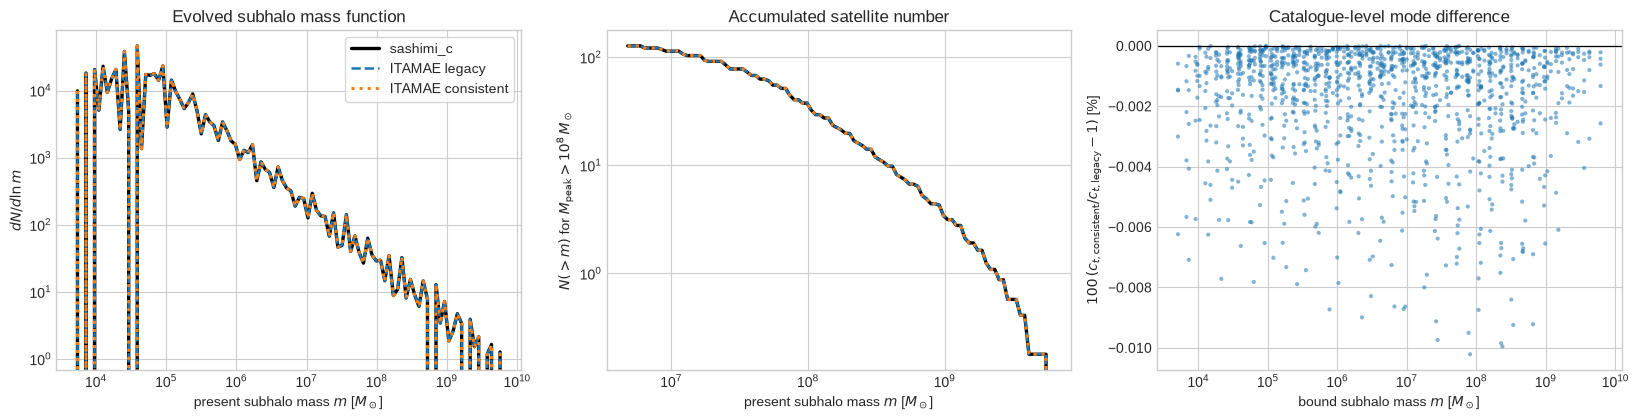

In [6]:
m_established, dndlnm_established = legacy_observables.mass_function(evolved=True)
m_legacy, dndlnm_legacy = migrated_legacy_observables.mass_function(evolved=True)
m_consistent, dndlnm_consistent = consistent_observables.mass_function(evolved=True)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.3))
axes[0].loglog(m_established, dndlnm_established, color="black", lw=2.4, label="sashimi_c")
axes[0].loglog(m_legacy, dndlnm_legacy, "--", lw=1.8, label="ITAMAE legacy")
axes[0].loglog(m_consistent, dndlnm_consistent, ":", lw=2.2, label="ITAMAE consistent")
axes[0].set_xlabel(r"present subhalo mass $m$ [$M_\odot$]")
axes[0].set_ylabel(r"$dN/d\ln m$")
axes[0].set_title("Evolved subhalo mass function")
axes[0].legend(frameon=True)

axes[1].loglog(legacy_mpeak[0], legacy_mpeak[1], color="black", lw=2.4, label="sashimi_c")
axes[1].loglog(migrated_mpeak[0], migrated_mpeak[1], "--", lw=1.8, label="ITAMAE legacy")
axes[1].loglog(consistent_mpeak[0], consistent_mpeak[1], ":", lw=2.2, label="ITAMAE consistent")
axes[1].set_xlabel(r"present subhalo mass $m$ [$M_\odot$]")
axes[1].set_ylabel(r"$N(>m)$ for $M_{\rm peak}>10^8\,M_\odot$")
axes[1].set_title("Accumulated satellite number")

m_bound = legacy_mode_catalog.columns["m_bound"] / legacy_observables.Msun
ct_legacy = legacy_mode_catalog.columns["c_t"]
ct_consistent = consistent_catalog.columns["c_t"]
ct_percent_shift = 100.0 * (ct_consistent / ct_legacy - 1.0)
axes[2].scatter(m_bound, ct_percent_shift, s=9, alpha=0.55, edgecolors="none")
axes[2].axhline(0.0, color="black", lw=0.9)
axes[2].set_xscale("log")
axes[2].set_xlabel(r"bound subhalo mass $m$ [$M_\odot$]")
axes[2].set_ylabel(r"$100\,(c_{t,\mathrm{consistent}}/c_{t,\mathrm{legacy}}-1)$ [%]")
axes[2].set_title("Catalogue-level mode difference")

fig.tight_layout()
plt.show()

## Interpretation

- `physics_mode="legacy"` is the migration acceptance path: it reproduces the established tuple, mass functions, and cumulative satellite counts to floating-point precision.
- `physics_mode="consistent"` is the opt-in default. It keeps the same public methods and the same canonical SASHIMI-C cosmology, but uses a single ITAMAE/SASHIMI constant convention and a bracketed NFW inversion. On this grid the mass function and satellite counts are visually unchanged, while profile quantities such as $r_s$, $\rho_s$, and $c_t$ retain a small, traceable shift.
- `subhalo_properties_calc` remains available when tuple compatibility is required. New analyses can prefer `subhalo_catalog_calc` for named fields, split population/concentration/survival weights, and provenance metadata.